# Exercise 1 In this exercise you should implement everything including the tests (e.g. the chi-square and KS tests) yourself. I recommend that you also code routines for histograms yourself to better control limits, but this is not strictly needed. Later, when your code is working you are free to use builtin functions.

## 1. Write a program implementing a linear congruential generator (LCG). Be sure that the program works correctly using only integer representation.

### **(a)** Generate 10.000 (pseudo-) random numbers and present these numbers in a histogramme (e.g. 10 classes).

For part 1(a), I implemented a linear congruential generator because the purpose of the exercise is to understand how pseudo-random numbers can be generated using a simple deterministic formula. The generator is based on the formula
$$
x_i = (a x_{i-1} + b) \text{mod M},
$$
where the next value depends on the previous value, the multiplier a, the increment b, and the modulus M. I use the modulo operation because it keeps the generated integer values within a fixed range from $0$ to $M - 1$. This is important because computers work with finite integer values, and the generator must therefore be implemented using integer arithmetic.

After generating each integer value $x_i$, I divide it by M to transform it into a number between $0$ and $1$:
$$
U_i = x_i / M.
$$

I do this because stochastic simulation usually requires random numbers that behave like values from a uniform distribution on the interval $[0,1)$. The lecture slides also describe this as the standard way of obtaining pseudo-random numbers from an LCG.

In this experiment, I generated $10,000$ pseudo-random numbers. I chose $10,000$ values because the sample should be large enough to make it possible to visually evaluate whether the numbers are approximately uniformly distributed. If the sample is too small, random variation may make the histogram difficult to interpret.

I then plotted the generated numbers in a histogram with 10 classes. I use a histogram because it gives a simple visual check of whether the numbers are evenly spread across the interval $[0,1)$. Since I generated $10,000$ numbers and used 10 classes, I would expect around 1,000 observations in each class if the generator behaves approximately uniformly.

The purpose of this step is therefore not to prove that the generator is good, but to get a first graphical impression of whether the generated values look reasonably uniform.

In [23]:
import matplotlib.pyplot as plt

# Number of pseudo-random numbers
n = 10000

# Starting value
seed = 12345

# LCG parameters
a = 1664525
b = 1013904223
M = 2**32

# Start from the seed
x = seed

# Store generated numbers here
numbers = []

# Generate 10,000 numbers
for i in range(n):
    x = (a * x + b) % M
    u = x / M
    numbers.append(u)

# Print first few numbers to check
print(numbers[:10])

[0.02040268573909998, 0.01654784823767841, 0.5431557944975793, 0.6349040560889989, 0.9100295137614012, 0.11246166913770139, 0.4958894052542746, 0.5483488442841917, 0.5961001170799136, 0.7834504160564393]


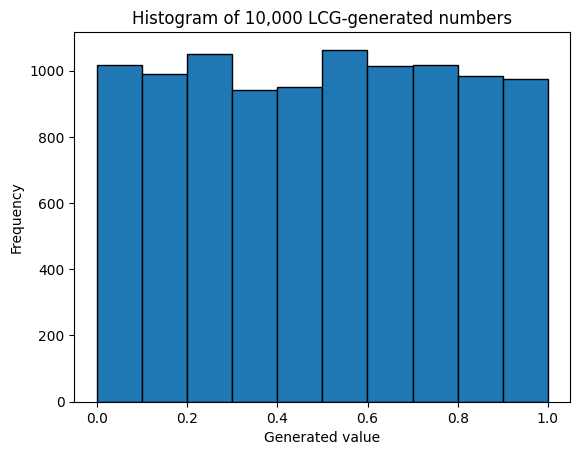

In [24]:
# Make histogram with 10 classes
plt.hist(numbers, bins=10, edgecolor="black")
plt.xlabel("Generated value")
plt.ylabel("Frequency")
plt.title("Histogram of 10,000 LCG-generated numbers")
plt.show()

### **(b)** Evaluate the quality of the generator by graphical descriptive statistics (histogrammes, scatter plots) and statistical tests - $\chi^2$, Kolmogorov-Smirnov, run-tests preferably but not necessarily all 3, and correlation test for some $h$-values.

For part 1(b), I evaluate the quality of the generator from part 1(a). I do this because generating numbers is not enough by itself. The numbers also need to behave like random numbers. In stochastic simulation, we usually want numbers that are approximately uniformly distributed on [0,1) and approximately independent of each other.

First, I use a histogram to visually check whether the generated values are evenly spread across the interval $[0,1)$. I do this because a uniform distribution should give approximately the same number of observations in each interval. Since I generated $10,000$ values and used $10$ bins, I expect around $1,000$ values in each bin. If the histogram is approximately flat, this supports that the generator is close to uniform.

Second, I use a scatter plot of $U_i$ against $U_{i+1}$. I do this because it helps me see whether there are clear patterns between one generated value and the next. If the generator behaves well, the points should look like a random cloud. If there are visible lines, curves, or clusters, it may indicate dependence between the values.

I then use a chi-square test to test uniformity more formally. I divide the interval $[0,1)$ into $10$ bins and compare the observed number of values in each bin with the expected number. The expected number is $1,000$ in each bin. A small chi-square value means that the observed bin counts are close to what we would expect from a uniform distribution. If the chi-square value is below the critical value, I do not reject that the values are uniformly distributed.

I also use the Kolmogorov-Smirnov test as another test of uniformity. I do this because the KS test compares the empirical distribution of the generated numbers with the theoretical uniform distribution without using bins. This gives another way to check whether the generated numbers follow a uniform distribution. If the KS value is below the critical value, I do not reject uniformity.

To test independence, I use a runs test. I divide the values into two groups: values below $0.5$ and values above or equal to $0.5$. I then count how often the sequence switches between these two groups. I do this because a random sequence should not stay too long in one group or switch too often. If the z-value is between $-1.96$ and $1.96$, I do not reject independence at the $5\%$ level.

Finally, I calculate correlations between $U_i$ and $U_{i+h}$ for different values of h, for example $h = 1, 2, 5$ and $10$. I do this because values in a good random sequence should not be strongly related to later values in the sequence. If the correlations are close to zero, this supports that there is no strong linear dependence.

Overall, these graphical and statistical tests do not prove that the generator is perfect, but they help identify whether there are obvious problems with uniformity or independence.

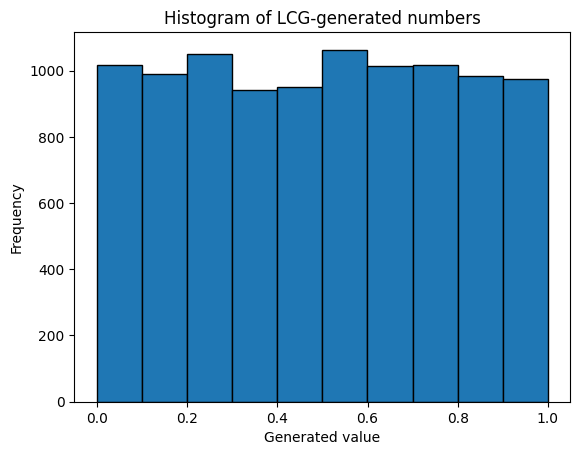

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.hist(numbers, bins=10, edgecolor="black")
plt.xlabel("Generated value")
plt.ylabel("Frequency")
plt.title("Histogram of LCG-generated numbers")
plt.show()

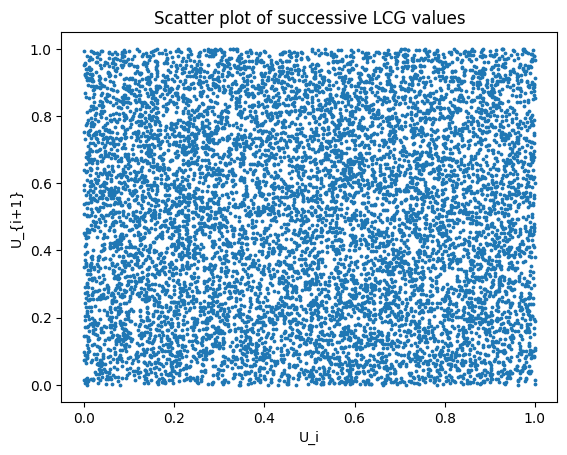

In [26]:
# --------------------------------------------------
# Scatter plot: U_i against U_{i+1}
# --------------------------------------------------

plt.scatter(numbers[:-1], numbers[1:], s=3)
plt.xlabel("U_i")
plt.ylabel("U_{i+1}")
plt.title("Scatter plot of successive LCG values")
plt.show()

In [27]:
# --------------------------------------------------
# Chi-square test
# --------------------------------------------------

n = len(numbers)
bins = 10

counts = [0] * bins

for u in numbers:
    index = int(u * bins)

    if index == bins:
        index = bins - 1

    counts[index] += 1

expected = n / bins

chi_square = 0

for observed in counts:
    chi_square += (observed - expected) ** 2 / expected

print("Chi-square test")
print("Observed counts:", counts)
print("Expected count in each bin:", expected)
print("Chi-square value:", chi_square)

# Critical value for chi-square with 9 degrees of freedom at 5% level
critical_chi_square = 16.92

if chi_square < critical_chi_square:
    print("Conclusion: Do not reject uniformity")
else:
    print("Conclusion: Reject uniformity")

Chi-square test
Observed counts: [1016, 993, 1049, 940, 949, 1063, 1014, 1016, 984, 976]
Expected count in each bin: 1000.0
Chi-square value: 14.16
Conclusion: Do not reject uniformity


In [28]:
# --------------------------------------------------
# Kolmogorov-Smirnov test
# --------------------------------------------------

sorted_numbers = sorted(numbers)

largest_difference = 0

for i in range(n):
    empirical_value = (i + 1) / n
    theoretical_value = sorted_numbers[i]

    difference = abs(empirical_value - theoretical_value)

    if difference > largest_difference:
        largest_difference = difference

ks_value = largest_difference

critical_ks = 1.36 / np.sqrt(n)

print()
print("Kolmogorov-Smirnov test")
print("KS value:", ks_value)
print("Critical value:", critical_ks)

if ks_value < critical_ks:
    print("Conclusion: Do not reject uniformity")
else:
    print("Conclusion: Reject uniformity")


Kolmogorov-Smirnov test
KS value: 0.0059602058928460155
Critical value: 0.013600000000000001
Conclusion: Do not reject uniformity


In [29]:
# --------------------------------------------------
# Runs test
# --------------------------------------------------

signs = []

for u in numbers:
    if u < 0.5:
        signs.append(0)
    else:
        signs.append(1)

runs = 1

for i in range(1, n):
    if signs[i] != signs[i - 1]:
        runs += 1

n0 = signs.count(0)
n1 = signs.count(1)

expected_runs = 1 + (2 * n0 * n1) / (n0 + n1)

variance_runs = (
    2 * n0 * n1 * (2 * n0 * n1 - n0 - n1)
    / (((n0 + n1) ** 2) * (n0 + n1 - 1))
)

z_value = (runs - expected_runs) / np.sqrt(variance_runs)

print()
print("Runs test")
print("Number below 0.5:", n0)
print("Number above/equal to 0.5:", n1)
print("Observed runs:", runs)
print("Expected runs:", expected_runs)
print("Z-value:", z_value)

if abs(z_value) < 1.96:
    print("Conclusion: Do not reject independence")
else:
    print("Conclusion: Reject independence")


Runs test
Number below 0.5: 4947
Number above/equal to 0.5: 5053
Observed runs: 5120
Expected runs: 5000.4382
Z-value: 2.3916243325147284
Conclusion: Reject independence


In [30]:
# --------------------------------------------------
# Correlation test for different h-values
# --------------------------------------------------

print()
print("Correlation test")

for h in [1, 2, 5, 10]:
    x_values = numbers[:-h]
    y_values = numbers[h:]

    correlation = np.corrcoef(x_values, y_values)[0, 1]

    print("h =", h, "correlation =", correlation)


Correlation test
h = 1 correlation = -0.015313329079647747
h = 2 correlation = -0.00046419931998707573
h = 5 correlation = -0.011822144157987088
h = 10 correlation = 0.01062625297273893


###  **(c)** Repeat (a) and (b) by experimenting with different values of “a”, “b” and “M”. In the end you should have a decent generator. Report at least one bad and your final choice.

First 20 values from bad generator:
[0.0, 0.0625, 0.375, 0.9375, 0.75, 0.8125, 0.125, 0.6875, 0.5, 0.5625, 0.875, 0.4375, 0.25, 0.3125, 0.625, 0.1875, 0.0, 0.0625, 0.375, 0.9375]


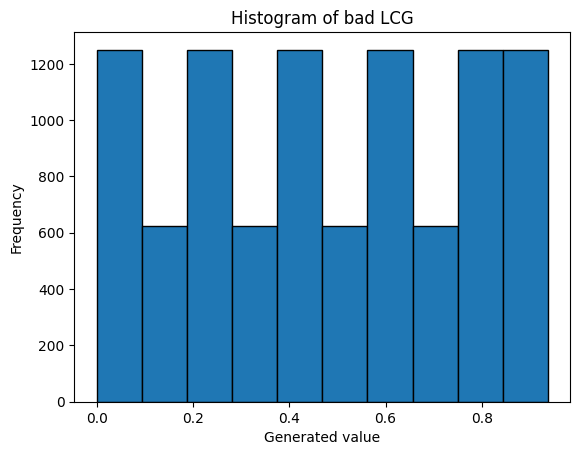

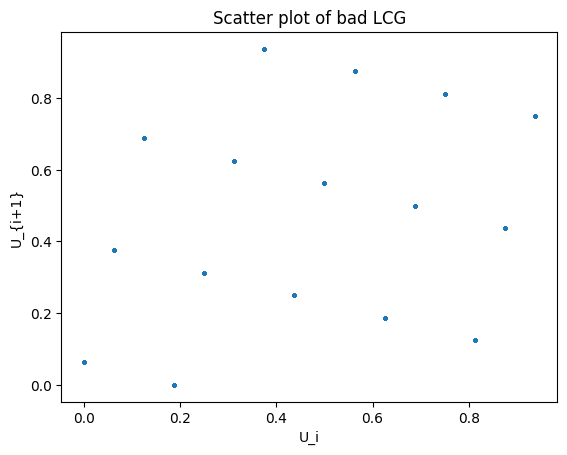

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# BAD GENERATOR
# --------------------------------------------------

n = 10000

bad_seed = 3
bad_a = 5
bad_b = 1
bad_M = 16

x = bad_seed
bad_numbers = []

for i in range(n):
    x = (bad_a * x + bad_b) % bad_M
    u = x / bad_M
    bad_numbers.append(u)

print("First 20 values from bad generator:")
print(bad_numbers[:20])

plt.hist(bad_numbers, bins=10, edgecolor="black")
plt.xlabel("Generated value")
plt.ylabel("Frequency")
plt.title("Histogram of bad LCG")
plt.show()

plt.scatter(bad_numbers[:-1], bad_numbers[1:], s=3)
plt.xlabel("U_i")
plt.ylabel("U_{i+1}")
plt.title("Scatter plot of bad LCG")
plt.show()

In [32]:
# --------------------------------------------------
# CHI-SQUARE TEST FOR BAD GENERATOR
# --------------------------------------------------

bins = 10
counts = [0] * bins

for u in bad_numbers:
    index = int(u * bins)

    if index == bins:
        index = bins - 1

    counts[index] += 1

expected = n / bins

chi_square = 0

for observed in counts:
    chi_square += (observed - expected) ** 2 / expected

print("Bad generator counts:")
print(counts)

print("Bad generator chi-square value:")
print(chi_square)

Bad generator counts:
[1250, 1250, 625, 1250, 625, 1250, 1250, 625, 1250, 625]
Bad generator chi-square value:
937.5


First 20 values from final generator:
[0.02040268573909998, 0.01654784823767841, 0.5431557944975793, 0.6349040560889989, 0.9100295137614012, 0.11246166913770139, 0.4958894052542746, 0.5483488442841917, 0.5961001170799136, 0.7834504160564393, 0.03985431743785739, 0.743801222415641, 0.9658093675971031, 0.07366754091344774, 0.6996069294400513, 0.4602941742632538, 0.39648351538926363, 0.959521286888048, 0.40612530102953315, 0.9527641565073282]


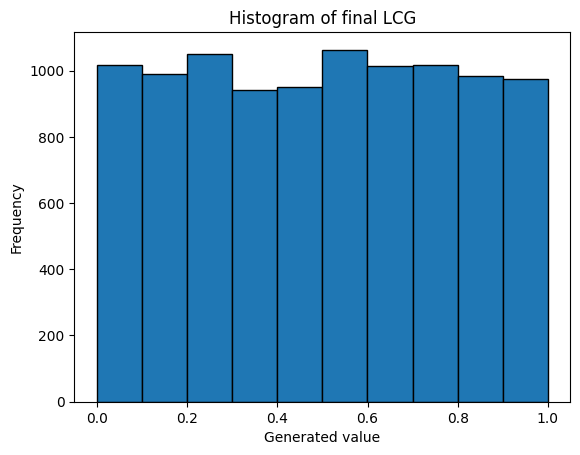

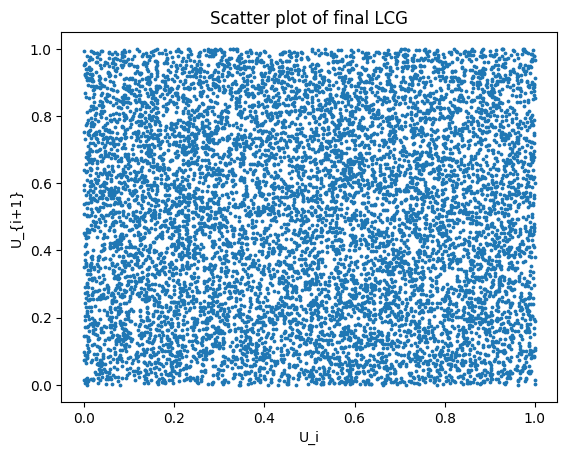

In [33]:
# --------------------------------------------------
# FINAL / BETTER GENERATOR
# --------------------------------------------------

good_seed = 12345
good_a = 1664525
good_b = 1013904223
good_M = 2**32

x = good_seed
good_numbers = []

for i in range(n):
    x = (good_a * x + good_b) % good_M
    u = x / good_M
    good_numbers.append(u)

print("First 20 values from final generator:")
print(good_numbers[:20])

plt.hist(good_numbers, bins=10, edgecolor="black")
plt.xlabel("Generated value")
plt.ylabel("Frequency")
plt.title("Histogram of final LCG")
plt.show()

plt.scatter(good_numbers[:-1], good_numbers[1:], s=3)
plt.xlabel("U_i")
plt.ylabel("U_{i+1}")
plt.title("Scatter plot of final LCG")
plt.show()


In [34]:
# --------------------------------------------------
# CHI-SQUARE TEST FOR FINAL GENERATOR
# --------------------------------------------------

bins = 10
counts = [0] * bins

for u in good_numbers:
    index = int(u * bins)

    if index == bins:
        index = bins - 1

    counts[index] += 1

expected = n / bins

chi_square = 0

for observed in counts:
    chi_square += (observed - expected) ** 2 / expected

print("Final generator counts:")
print(counts)

print("Final generator chi-square value:")
print(chi_square)

Final generator counts:
[1016, 993, 1049, 940, 949, 1063, 1014, 1016, 984, 976]
Final generator chi-square value:
14.16


In [35]:
# --------------------------------------------------
# CORRELATION TEST FOR FINAL GENERATOR
# --------------------------------------------------

print("Correlation test for final generator:")

for h in [1, 2, 5, 10]:
    x_values = good_numbers[:-h]
    y_values = good_numbers[h:]

    correlation = np.corrcoef(x_values, y_values)[0, 1]

    print("h =", h)
    print("correlation =", correlation)
    

Correlation test for final generator:
h = 1
correlation = -0.015313329079647747
h = 2
correlation = -0.00046419931998707573
h = 5
correlation = -0.011822144157987088
h = 10
correlation = 0.01062625297273893


## 2. Apply a system available generator and perform the various statistical tests you did under Part 1 point (b) for this generator too.

For task 2, I use a system available random number generator and apply the same graphical and statistical tests as in task 1. I do this because I want to compare my own LCG with a generator that is already built into Python.

I use Python's random.random() function to generate 10,000 pseudo-random numbers between 0 and 1. I also set a seed before generating the numbers, because this makes the result reproducible. This means that the same sequence can be generated again if the same seed is used.

First, I make a histogram of the generated values. I do this to visually check whether the numbers are approximately uniformly distributed on the interval $[0,1)$. Since I generate 10,000 values and use 10 bins, I expect around 1,000 values in each bin if the generator behaves uniformly.

Second, I make a scatter plot of $U_i$ against $U_{i+1}$. I do this to check whether there are visible patterns between one value and the next. If the points look like a random cloud, this supports that the numbers behave independently. If there are lines, curves, or clusters, this could indicate dependence.

I then use the chi-square test to test uniformity. The interval $[0,1)$ is divided into 10 bins, and the observed counts are compared with the expected count of 1,000 in each bin. If the chi-square value is below the critical value, I do not reject uniformity.

I also use the Kolmogorov-Smirnov test. I do this because the KS test compares the empirical distribution of the generated numbers with the theoretical uniform distribution without using bins. This gives an additional test of uniformity.

To test independence, I use a runs test. I divide the numbers into values below 0.5 and values above or equal to 0.5. I then count how often the sequence switches between the two groups. If the z-value is between -1.96 and 1.96, I do not reject independence.

Finally, I calculate correlations between $U_i$ and $U_{i+h}$ for $h = 1, 2, 5, and 10$. I do this because a good generator should not have strong correlation between values in the sequence. Correlations close to zero support that there is no strong linear dependence.

Overall, the system generator performs well if the histogram is approximately flat, the scatter plot has no clear pattern, the uniformity tests are not rejected, and the correlations are close to zero.

This code do not use the function

In [36]:
import random
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# TASK 2: SYSTEM AVAILABLE GENERATOR
# --------------------------------------------------

n = 10000

# Set seed so the result can be reproduced
random.seed(12345)

system_numbers = []

for i in range(n):
    u = random.random()
    system_numbers.append(u)

print("First 10 numbers from the system generator:")
print(system_numbers[:10])

First 10 numbers from the system generator:
[0.41661987254534116, 0.010169169457068361, 0.8252065092537432, 0.2986398551995928, 0.3684116894884757, 0.19366134904507426, 0.5660081687288613, 0.1616878239293682, 0.12426688428353017, 0.4329362680099159]


Histogram

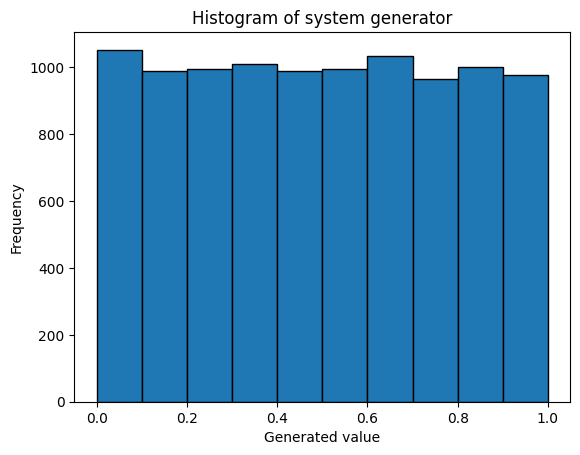

In [37]:
plt.hist(system_numbers, bins=10, edgecolor="black")
plt.xlabel("Generated value")
plt.ylabel("Frequency")
plt.title("Histogram of system generator")
plt.show()

Scatterplot

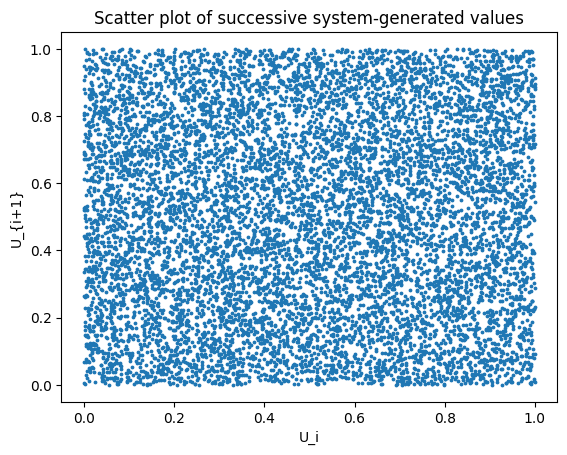

In [38]:
plt.scatter(system_numbers[:-1], system_numbers[1:], s=3)
plt.xlabel("U_i")
plt.ylabel("U_{i+1}")
plt.title("Scatter plot of successive system-generated values")
plt.show()

chi-square test

In [39]:
bins = 10
counts = [0] * bins

for u in system_numbers:
    index = int(u * bins)

    if index == bins:
        index = bins - 1

    counts[index] += 1

expected = n / bins

chi_square = 0

for observed in counts:
    chi_square += (observed - expected) ** 2 / expected

critical_chi_square = 16.92

print("Chi-square test")
print("Observed counts:", counts)
print("Expected count in each bin:", expected)
print("Chi-square value:", chi_square)
print("Critical value:", critical_chi_square)

if chi_square < critical_chi_square:
    print("Conclusion: Do not reject uniformity")
else:
    print("Conclusion: Reject uniformity")

Chi-square test
Observed counts: [1052, 988, 994, 1008, 989, 994, 1032, 965, 1001, 977]
Expected count in each bin: 1000.0
Chi-square value: 5.884000000000001
Critical value: 16.92
Conclusion: Do not reject uniformity


Kolmogorov-Smirnov test

In [40]:
sorted_numbers = sorted(system_numbers)

largest_difference = 0

for i in range(n):
    empirical_value = (i + 1) / n
    theoretical_value = sorted_numbers[i]

    difference = abs(empirical_value - theoretical_value)

    if difference > largest_difference:
        largest_difference = difference

ks_value = largest_difference
critical_ks = 1.36 / np.sqrt(n)

print()
print("Kolmogorov-Smirnov test")
print("KS value:", ks_value)
print("Critical value:", critical_ks)

if ks_value < critical_ks:
    print("Conclusion: Do not reject uniformity")
else:
    print("Conclusion: Reject uniformity")


Kolmogorov-Smirnov test
KS value: 0.007728401262577345
Critical value: 0.013600000000000001
Conclusion: Do not reject uniformity


Runs test

In [41]:
signs = []

for u in system_numbers:
    if u < 0.5:
        signs.append(0)
    else:
        signs.append(1)

runs = 1

for i in range(1, n):
    if signs[i] != signs[i - 1]:
        runs += 1

n0 = signs.count(0)
n1 = signs.count(1)

expected_runs = 1 + (2 * n0 * n1) / (n0 + n1)

variance_runs = (
    2 * n0 * n1 * (2 * n0 * n1 - n0 - n1)
    / (((n0 + n1) ** 2) * (n0 + n1 - 1))
)

z_value = (runs - expected_runs) / np.sqrt(variance_runs)

print()
print("Runs test")
print("Number below 0.5:", n0)
print("Number above/equal to 0.5:", n1)
print("Observed runs:", runs)
print("Expected runs:", expected_runs)
print("Z-value:", z_value)

if abs(z_value) < 1.96:
    print("Conclusion: Do not reject independence")
else:
    print("Conclusion: Reject independence")


Runs test
Number below 0.5: 5031
Number above/equal to 0.5: 4969
Observed runs: 4904
Expected runs: 5000.8078
Z-value: -1.9363272646091652
Conclusion: Do not reject independence


Correlation test

In [42]:
print()
print("Correlation test")

for h in [1, 2, 5, 10]:
    x_values = system_numbers[:-h]
    y_values = system_numbers[h:]

    correlation = np.corrcoef(x_values, y_values)[0, 1]

    print("h =", h)
    print("Correlation =", correlation)


Correlation test
h = 1
Correlation = 0.01728139061592588
h = 2
Correlation = 0.0029728129128910527
h = 5
Correlation = -0.01052055555054319
h = 10
Correlation = 0.0016023528469423156


## 3. You were asked to simulate one sample and perform tests on this sample. Discuss the sufficiency of this approach and take action, if needed.

In task 3, I discuss whether it is enough to simulate one sample and perform tests on that sample. I do not think one sample is enough, because one sample only shows how the generator behaves in one specific situation.

A random number generator may look good in one sample, but this does not prove that it will always behave well. For example, a bad generator could pass a test by chance. In the same way, a good generator could fail one test by chance because of random variation in the sample.

This is important because the purpose of a random number generator is not only to produce one good-looking sequence. It should produce sequences that are generally useful for simulation. In stochastic simulation, we usually want numbers that behave like independent values from a uniform distribution on $[0,1)$. Therefore, it is better to test the generator several times.

To take action, I repeated the tests using different seed values. I used the same LCG parameters, but changed the seed. This makes it possible to see whether the generator gives reasonable results for different starting points.

For each seed, I calculated the chi-square value, the Kolmogorov-Smirnov value, and the correlation for $h = 1$. If the generator gives reasonable results for several seeds, this gives stronger evidence that it is useful than testing only one sample.

However, even if the generator passes these tests for several seeds, this still does not prove that it is perfect. It only means that these tests did not find obvious problems. More tests and larger samples could be used if the generator were needed for more serious simulation work.

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# TASK 3: REPEATING THE TEST WITH DIFFERENT SEEDS
# --------------------------------------------------

n = 10000

a = 1664525
b = 1013904223
M = 2**32

seeds = [1, 2, 3, 4, 5]

for seed in seeds:

    x = seed
    numbers = []

    for i in range(n):
        x = (a * x + b) % M
        u = x / M
        numbers.append(u)

    # Chi-square test
    bins = 10
    counts = [0] * bins

    for u in numbers:
        index = int(u * bins)

        if index == bins:
            index = bins - 1

        counts[index] += 1

    expected = n / bins

    chi_square = 0

    for observed in counts:
        chi_square += (observed - expected) ** 2 / expected

    # KS test
    sorted_numbers = sorted(numbers)

    largest_difference = 0

    for i in range(n):
        empirical_value = (i + 1) / n
        theoretical_value = sorted_numbers[i]

        difference = abs(empirical_value - theoretical_value)

        if difference > largest_difference:
            largest_difference = difference

    ks_value = largest_difference

    # Correlation test for h = 1
    x_values = numbers[:-1]
    y_values = numbers[1:]

    correlation = np.corrcoef(x_values, y_values)[0, 1]

    print("Seed:", seed)
    print("Counts:", counts)
    print("Chi-square value:", chi_square)
    print("KS value:", ks_value)
    print("Correlation for h = 1:", correlation)
    print()

Seed: 1
Counts: [1012, 1017, 1029, 1001, 970, 973, 1003, 1024, 994, 977]
Chi-square value: 4.054
KS value: 0.007874301645532267
Correlation for h = 1: 0.004409526734278759

Seed: 2
Counts: [1008, 983, 972, 1026, 1030, 1030, 960, 1012, 933, 1046]
Chi-square value: 11.962
KS value: 0.005676604767888782
Correlation for h = 1: -0.00880373458201364

Seed: 3
Counts: [981, 1016, 1004, 1044, 1084, 967, 1019, 999, 934, 952]
Chi-square value: 17.736
KS value: 0.013989249201118992
Correlation for h = 1: -0.01331424428088241

Seed: 4
Counts: [977, 949, 996, 1020, 995, 1025, 1040, 987, 972, 1039]
Chi-square value: 8.27
KS value: 0.009334472779929631
Correlation for h = 1: -0.005601792587416612

Seed: 5
Counts: [957, 993, 983, 1018, 1061, 1002, 1021, 957, 985, 1023]
Chi-square value: 9.279999999999998
KS value: 0.008239870338141941
Correlation for h = 1: -0.01539423906371845

